## The MA Model

The MA model, short for the `Moving Average model`, is the second important building 
block in univariate time series. Like the AR model, it is a building block 
that is more often used as a part of more complex time series, but it can also be used as a 
stand-alone.

Where the AR model looks at lagged 
values of the target variable to predict the future, the MA model looks at the model error 
of past predictions.

In a way, the model error in the past influences the future, and past errors can help 
you to make a forecast. This is the idea behind the MA model.

the 
MA model seems relatively comparable to an AR model: MA depends on past errors, 
whereas the AR model depends on past values.

*** Important *** to note is that the MA model has an absolute need for stationarity. Where the 
AR model can adapt to non-stationary situations, the MA model cannot. 

Check page 74 for indicators that show when to use AR or MA.

In [2]:
# Importing stock price data using the Yahoo Finance package

import yfinance as yf

data = yf.download(
    'MSFT',
    start='2019-01-01',
    end='2019-12-31',
    auto_adjust=False
)

data = data['Close']
data

[*********************100%***********************]  1 of 1 completed


Ticker,MSFT
Date,
2019-01-02,101.120003
2019-01-03,97.400002
2019-01-04,101.930000
2019-01-07,102.059998
2019-01-08,102.800003
...,...
2019-12-23,157.410004
2019-12-24,157.380005
2019-12-26,158.669998


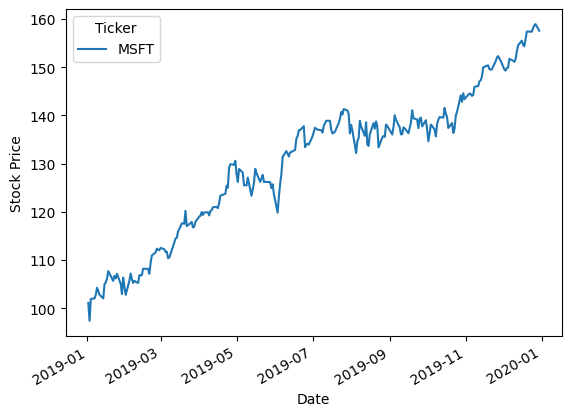

In [3]:
## Plotting the stock price data
import matplotlib.pyplot as plt

ax = data.plot()
ax.set_ylabel("Stock Price")
plt.show()

In this graph, you can clearly see an upward trend. It is not even necessary to apply 
an Augmented Dickey Fuller (ADF) test here to see that this data is not stationary. 
Since the MA model cannot function without stationarity, let’s apply the go-to solution: 
differencing.

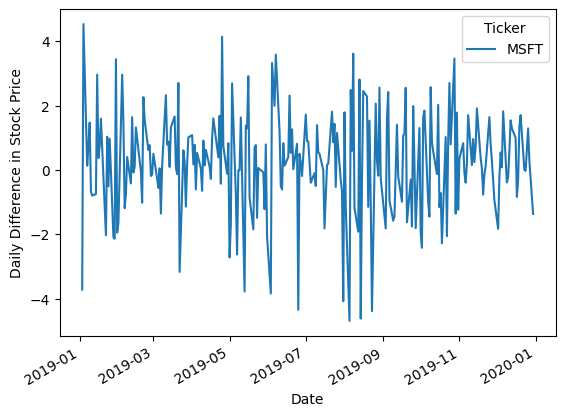

In [4]:
## Computing the differenced data and plotting it
# Need to difference

data = data.diff().dropna()
ax = data.plot()
ax.set_ylabel("Daily Difference in Stock Price")
plt.show()

The differenced data looks stationary but for consistency sake we will apply ADF test

In [7]:
# Applying an ADF test to the differenced data
from statsmodels.tsa.stattools import adfuller

result = adfuller(data)

pvalue = result[1]

if pvalue < 0.05:
    print('stationary', result[1])
else:
    print('not stationary',result[1])

stationary 1.0018352093793588e-13


This confirms stationarity of the differenced series. Let’s have a look at the 
autocorrelation and partial autocorrelation functions to see whether there is an obvious 
choice for the lag

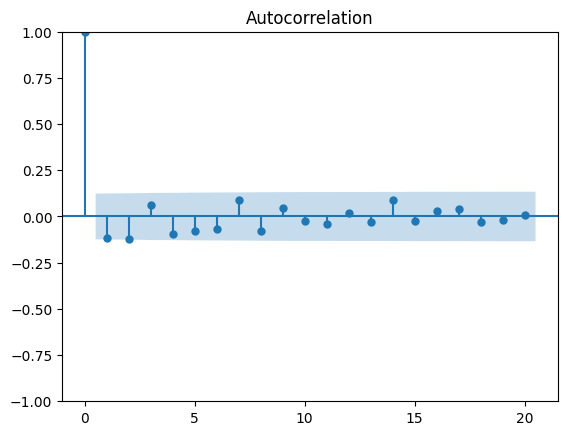

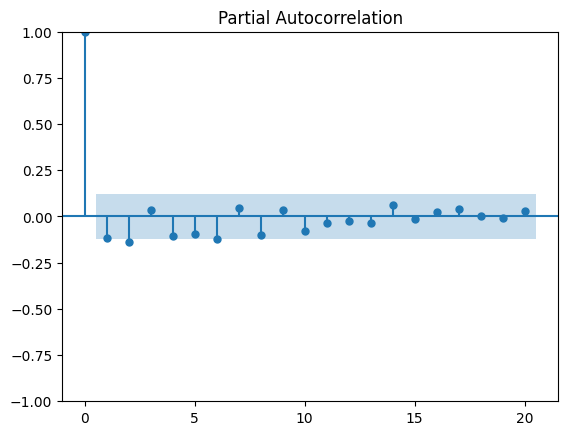

In [6]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(data, lags=20)
plot_pacf(data, lags=20)
plt.show()

You can observe some decay 
in the partial autocorrelation function, which is a positive sign for using a time series 
approach. But nothing too obvious on the choice of lag. Let’s fit the MA model with order 
1 and see what it does.

c:\Users\pc\Downloads\Python_TimeSeriesAnalysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\pc\Downloads\Python_TimeSeriesAnalysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\pc\Downloads\Python_TimeSeriesAnalysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


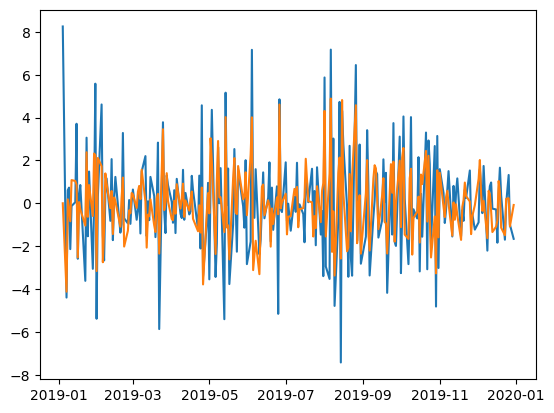

0.514184614099716


In [8]:
# Fitting the MA model and plotting the forecast

from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA

# Forecast the first MA(1) model
mod = ARIMA(data.diff().dropna(), order=(0,0,1))
res = mod.fit()

orig_data = data.diff().dropna()
pred = res.predict()

plt.plot(orig_data)
plt.plot(pred)
plt.show()
print(r2_score(orig_data, pred))

This plot looks not too bad: the orange curve (predicted) follows the general trend in 
the blue curve (actual values). You can observe that the predicted curve is less extreme 
in its predictions (the highs are less high, and the lows are less low). `The R2 score is 0.51`.
As an interpretation, you could observe that there is an `underfit` in this model: it does 
capture the basics, but it does not capture enough of the trend to be a very good model. 

In [9]:
# At this stage, we can already have a check of its out-of-sample performance by creating a train and a test set

#Fitting the MA model on train data and evaluating the R2 score on train and test data
train = data.diff().dropna()[0:240]
test = data.diff().dropna()[240:250]

# Forecast the first MA(1) model
mod = ARIMA(train, order=(0,0,1))
res = mod.fit()
orig_data = data.diff().dropna()
pred = res.predict() ## predict the train data
fcst = res.forecast(steps = len(test)) ## forcast te next 10 diff. So we can compare with test data
print(r2_score(train, pred))
print(r2_score(test, fcst))

c:\Users\pc\Downloads\Python_TimeSeriesAnalysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\pc\Downloads\Python_TimeSeriesAnalysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\pc\Downloads\Python_TimeSeriesAnalysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


0.5152180828784239
0.11726209540635246


c:\Users\pc\Downloads\Python_TimeSeriesAnalysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\pc\Downloads\Python_TimeSeriesAnalysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


This performance on 
the training data is not good, and the performance on the test data is even worse (only 
12% of the variation in the test data can be explained by the MA model).

Let's visualize the test performance.

In [13]:
test

Ticker,MSFT
Date,
2019-12-17,-1.839996
2019-12-18,0.519989
2019-12-19,1.660019
2019-12-20,0.359985
2019-12-23,-1.699997
2019-12-24,-0.029999
2019-12-26,1.319992
2019-12-27,-0.999985
2019-12-30,-1.660019


In [17]:
fcst

240   -0.798775
241   -0.000203
242   -0.000203
243   -0.000203
244   -0.000203
245   -0.000203
246   -0.000203
247   -0.000203
248   -0.000203
Name: predicted_mean, dtype: float64

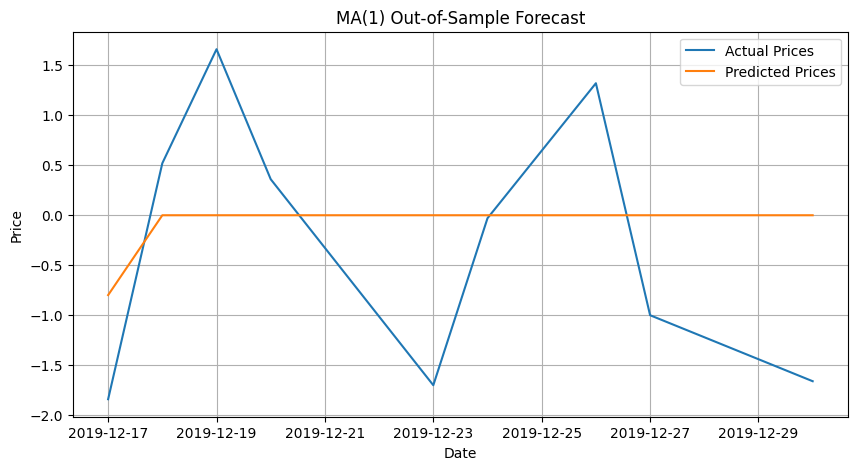

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(test.index, test.values, label='Actual Prices')
plt.plot(test.index, fcst, label='Predicted Prices')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('MA(1) Out-of-Sample Forecast')
plt.legend()
plt.grid(True)

plt.show()

But when looking at this visual, you can see that there is something weird going on 
with the forecast on the test set. The MA(1) forecast has forecasted the average for every 
value except for the first step into the future. Reason: ** READ ON PAGE 82 **

### Multistep Forecasting with Model Retraining

One-step forecasting is the basis. It is relatively easy to predict one step forward. 
Multistep forecasting is not an easy task using time series, as errors will accumulate with 
every step forward you take.
In many cases, the most accurate solution is to retrain the model each time step. 

In 
fact, it is possible to do this if you update the model as soon as you obtain a new data 
point. This means that you would do repeated one-step forecasts. In some cases, this can 
work, while in other cases it is necessary to forecast further in the future.

In [23]:
data

Ticker,MSFT
Date,
2019-01-03,-3.720001
2019-01-04,4.529999
2019-01-07,0.129997
2019-01-08,0.740005
2019-01-09,1.469994
...,...
2019-12-23,0.000000
2019-12-24,-0.029999
2019-12-26,1.289993


In [80]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import r2_score

# Make sure data is a Series
data = data.squeeze().astype(float)

# Difference the prices
diff_data = data.diff().dropna()

# Create train and test
train_n = diff_data.iloc[:240].reset_index(drop=True)
test_n = diff_data.iloc[240:250].reset_index(drop=True)

print(train_n.shape)
print(test_n.shape)

(240,)
(9,)


R²: 0.3852552933261325
[-0.7987751661803867, 1.0237004609421048, 0.4951652179791311, -1.1460229496123238, -1.481853912309696, 0.2144120263510899, 0.24043842692593048, -1.062298668890542, -0.06155159814837954]


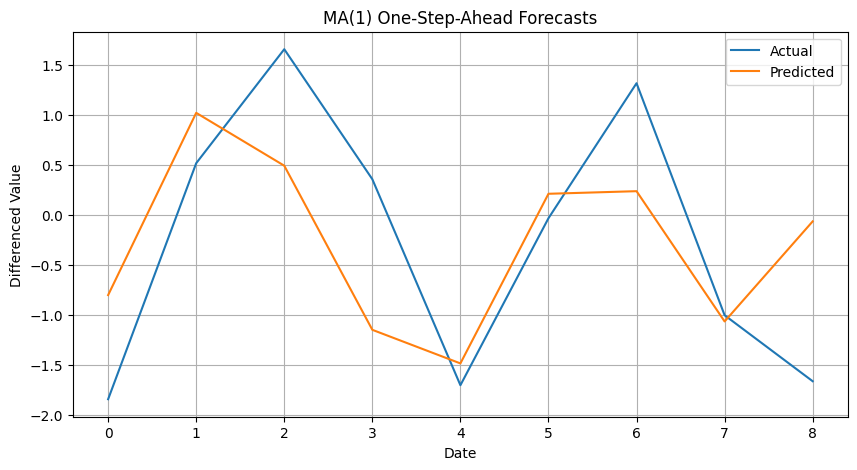

In [81]:
# Store forecasts
fcst = []

for step in range(len(test_n)):

    # Fit MA(1)
    mod = ARIMA(train_n, order=(0,0,1))
    res = mod.fit()

    # One-step-ahead forecast
    pred = res.forecast(steps=1)

    # Store forecast
    fcst += list(pred)

    # Add the actual observation to training data
    train_n.loc[len(train_n)] = test_n.iloc[step]

# Evaluate
print("R²:", r2_score(test_n.values, fcst))
print(fcst)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(test_n.index, test_n.values, label='Actual')
plt.plot(test_n.index, fcst, label='Predicted')

plt.xlabel('Date')
plt.ylabel('Differenced Value')
plt.title('MA(1) One-Step-Ahead Forecasts')
plt.legend()
plt.grid(True)
plt.show()

The R2 score that we obtain using this method is 0.38: not perfect, but this starts 
to look like something useful.

### Grid Search to Find the Best MA Order